## Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader           

from collections import Counter
from itertools import cycle
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, make_scorer, f1_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight

import skorch
from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from torch.optim.lr_scheduler import ReduceLROnPlateau
from functools import partial
from skorch.helper import predefined_split

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We chose glove over word2vec as the pretrained model has larger vocab more robust, more reasons why here, over us training our own word2vec embedding with our limited sample of n<5000 

we chose the 6B model with 100 dimensions as we are running our models on local and our compute power is limited. 

In [2]:
# Load preprocessed data
train = pd.read_csv('transformers_train_preprocessed.csv')
test = pd.read_csv('transformers_test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 5


In [3]:
# check 
train.head(5)

,Title,Link,Text,Source,Bias,special_symbol_length,special_symbol_proportion,cleaned_text
0,"Trump's Jan. 6 Pardons Come As a ""Betrayal"" to...",https://www.motherjones.com/politics/2025/01/t...,"Insurrectionists on Jan. 6, 2021 attacked Capi...",MotherJones,left,0,0.0,"Insurrectionists on Jan. 6, 2021 attacked Capi..."
1,GOP gov blasted over holiday post: 'Sit this o...,https://www.alternet.org/bill-lee-labor-day/,Tennessee Republican Governor Bill Lee faced b...,Alternet,left,0,0.0,Tennessee Republican Governor Bill Lee faced b...
2,"Senate Dems Praise Bondi's 'Competence,' Pivot...",https://freebeacon.com/politics/senate-dems-pr...,Attorney general nominee Pam Bondi vowed to ri...,TheWashingtonFreeBeacon,right,0,0.0,Attorney general nominee Pam Bondi vowed to ri...
3,Vance will make his mark as the first millenni...,https://apnews.com/article/jd-vance-vice-presi...,NEW YORK (AP) - As he prepares to become the n...,Apnews,left,0,0.0,NEW YORK (AP) - As he prepares to become the n...
4,Homan: Deportations Start Tomorrow with 'Every...,https://www.breitbart.com/clips/2025/01/20/hom...,On Monday's broadcast of the Fox Business Netw...,BreitBart,right,0,0.0,On Monday's broadcast of the Fox Business Netw...


## Global Variables

In [4]:
batch_size = 32
#embedding_dim = 100
#num_epochs = 20
criterion = nn.CrossEntropyLoss()
#lr = 0.01    ## these are overriden later 
torch.manual_seed(42)
np.random.seed(42)

## Build Vocab and Embeddings

In [5]:
def tokenize(text):
    return text.lower().split()
    
def build_vocab(texts):
    vocab = Counter()
    for text in texts:
        tokens = tokenize(text)
        vocab.update(tokens)
    return vocab

def load_glove_embeddings(glove_file, vocab, embedding_dim):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            # skip any malformed lines
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings_index[word] = vector

    # Special tokens
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    pad_vec = np.zeros(embedding_dim, dtype=np.float32)
    unk_vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)

    # Build list of vectors
    embedding_list = [pad_vec, unk_vec]
    for word in sorted(vocab):
        word2idx[word] = len(word2idx)
        vec = embeddings_index.get(word)
        if vec is None:
            vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)
        embedding_list.append(vec)

    embedding_matrix = np.asarray(embedding_list, dtype=np.float32)  # shape: (vocab_size, embedding_dim)
    print("Embedding matrix shape:", embedding_matrix.shape)
    embedding_tensor = torch.from_numpy(embedding_matrix)      # dtype=torch.float32

    return word2idx, embedding_tensor, embeddings_index


We use simple white space tokenizer to use with glove which is word based to feed words sequentially into LSTM. 

In [6]:
def encode_text(texts, word2idx, max_len=100):
    encoded = []
    for text in texts:
        tokens = tokenize(text)
        idxs = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
        if len(idxs) < max_len:
            idxs += [word2idx['<PAD>']] * (max_len - len(idxs))
        else:
            idxs = idxs[:max_len]
        encoded.append(idxs)
    return torch.tensor(encoded)

In [7]:
vocab = build_vocab(train['cleaned_text'])        
embedding_dim = 100

word2idx, embedding_tensor, embeddings_index = load_glove_embeddings(glove_file, vocab, embedding_dim)

# check embedding match:
idx = word2idx.get('trump')
# check loaded embedding tensor directly
print("Loaded embedding tensor first 5 dims:", embedding_tensor[idx][:5])
# compare with original GloVe
print("Original GloVe vector first 5 dims:", embeddings_index['trump'][:5])

Embedding matrix shape: (73420, 100)
Loaded embedding tensor first 5 dims: tensor([-0.1573, -0.7550,  0.3684, -0.1896, -0.1690])
Original GloVe vector first 5 dims: [-0.15731 -0.75503  0.36845 -0.18958 -0.16896]


In [8]:
max_len = 100  # maximum number of tokens per article; adjust if needed

# Encode texts to fixed‑length index tensors
X_train = encode_text(train['cleaned_text'], word2idx, max_len)
X_test = encode_text(test['cleaned_text'], word2idx, max_len)

# Convert label arrays to torch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

class EncodedTextDataset(Dataset):
    """Returns a tuple (encoded_text, label) for each item."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx]

# Create dataset instances
train_dataset = EncodedTextDataset(X_train, y_train_tensor)
test_dataset = EncodedTextDataset(X_test, y_test_tensor)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 55 | Test batches: 14


## LSTM

In [9]:
class LSTMModule(nn.Module):
    def __init__(self,
                 embedding_tensor,
                 hidden_dim=128,
                 num_layers=1,
                 bidirectional=False,
                 dropout=0.3,
                 num_classes=5):            
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor, freeze=True, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_tensor.size(1),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1),
                            num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        if self.bidirectional:
            feat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            feat = h_n[-1]
        return self.fc(feat)

We do not train the glove embedding or SFT it for now by setting freeze=True and lock padding index so that padding stays at zero and cannot drift. 

In [10]:
X_np = X_train.numpy()          # shape (N, seq_len)
y_np = y_train_tensor.numpy()

In [11]:
# Handled imbalanced classes

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_np), y=y_np)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [12]:
#for debugging 
USE_TEST_AS_VALID = False 

In [13]:
train_split = predefined_split(test_dataset) if USE_TEST_AS_VALID else ValidSplit(0.2, stratified=True)


net = NeuralNetClassifier(
    module=LSTMModule,
    module__embedding_tensor=embedding_tensor,
    criterion=partial(nn.CrossEntropyLoss, weight=class_weights_tensor),
    optimizer=torch.optim.Adam,
    lr=1e-3,
    batch_size=32,
    max_epochs=20,
    device=device,
    train_split=train_split,
    callbacks=[
        EpochScoring(scoring='f1_macro', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),
        LRScheduler(policy=ReduceLROnPlateau,
                    monitor='valid_loss',  
                    factor=0.5,
                    patience=2,
                    verbose=True),
        EarlyStopping(monitor='valid_loss', patience=5)
    ],
)

### Hyperparam Tuning

In [14]:

param_dist = {
    'module__hidden_dim':    [64, 128, 256],
    'module__num_layers':    [1, 2],
    'module__bidirectional': [False, True],
    'module__dropout':       [0.1, 0.3, 0.5],
    'lr':                    [0.0005, 0.001, 0.01],
    'batch_size':            [16, 32, 64],
}

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro'),
    'accuracy': make_scorer(accuracy_score)
}
search = RandomizedSearchCV(
    net,
    param_distributions=param_dist,
    n_iter=25,                
    cv=3,                     # 3‑fold inner CV
    scoring='f1_macro',       
    refit=True,               # keep best_ estimator
    verbose=2,
    n_jobs=1                  
)

search.fit(X_np, y_np)        # skorch handles GPU inside each fit

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.5542       0.4421      0.2152        2.1662  0.0100  1.4559
      2        1.2631       0.3562      0.2746        1.6191  0.0100  1.2415
      3        0.8576       0.3562      0.2607        1.7166  0.0100  1.2452
      4        0.5137       0.3948      0.3071        2.0407  0.0100  1.2547
      5        0.3241       0.4592      0.3317        2.2741  0.0100  1.2181
      6        0.1404       0.4378      0.3339        2.2817  0.0050  1.2507
Stopping since valid_loss has not improved in the last 5 epochs.
[CV] END batch_size=16, lr=0.01, module__bidirectional=True, module__dropout=0.1, module__hidden_dim=64, module__num_layers=1; total time=   9.9s


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.5793       0.4335      0.3171        1.5257  0.0100  1.2398
      2        1.3487       0.3863      0.2991        1.5248  0.0100  1.2583
      3        0.9402       0.4335      0.3213        1.7719  0.0100  1.2513
      4        0.6401       0.4034      0.3072        2.1118  0.0100  1.2303
      5        0.3807       0.3948      0.2712        2.4396  0.0100  1.2610
      6        0.1900       0.4421      0.3197        2.3752  0.0050  1.2522
Stopping since valid_loss has not improved in the last 5 epochs.
[CV] END batch_size=16, lr=0.01, module__bidirectional=True, module__dropout=0.1, module__hidden_dim=64, module__num_layers=1; total time=   9.1s


...

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.6058       0.3391      0.2749        1.5978  0.0010  0.4128
      2        1.5553       0.3691      0.2865        1.5713  0.0010  0.3468
      3        1.4985       0.3734      0.3134        1.5274  0.0010  0.3651
      4        1.4178       0.3519      0.3158        1.4973  0.0010  0.3597
      5        1.3274       0.3863      0.3333        1.4583  0.0010  0.3440
      6        1.2248       0.3863      0.3168        1.4617  0.0010  0.3636
      7        1.1005       0.4077      0.3495        1.4309  0.0010  0.3551
      8        1.0286       0.3948      0.3382        1.4462  0.0010  0.3568
      9        0.9507       0.3948      0.3425        1.4378  0.0010  0.4024
     10        0.8896       0.4206      0.3266        1.5192  0.0010  0.3684
     11        0.8001       0.4549      0.3636        1.6058  0.0005  0.3536

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.5987       0.3983      0.3312        1.4565  0.0100  1.9795
      2        1.2769       0.4040      0.3705        1.3974  0.0100  1.8976
      3        0.8674       0.4040      0.3446        1.5313  0.0100  1.9067
      4        0.5911       0.4585      0.3689        1.6875  0.0100  1.8897
      5        0.3548       0.4642      0.3682        1.8892  0.0100  2.0090
      6        0.1577       0.5072      0.3984        2.0820  0.0050  1.8927
Stopping since valid_loss has not improved in the last 5 epochs.


RandomizedSearchCV(cv=3,
                   estimator=NeuralNetClassifier(_params_to_validate={'module__embedding_tensor'}, batch_size=32, callbacks=[<skorch.callbacks.scoring.EpochScoring object at 0x3201a87a0>, <skorch.callbacks.scoring.EpochScoring object at 0x320733860>, <skorch.callbacks.lr_scheduler.LRScheduler object at 0x320733ce0>, <skorch.callbacks.training.EarlyStopping o...
        [-0.3063,  0.5324,  0.7960,  ..., -0.2002, -0.2802, -0.2156]]), optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, train_split=<skorch.dataset.ValidSplit object at 0x320733c50>, use_caching='auto', verbose=1, warm_start=False),
                   n_iter=25, n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64],
                                        'lr': [0.0005, 0.001, 0.01],
                                        'module__bidirectional': [False, True],
                                        'module__dropout': [0.1, 0.3, 0.5],
                                        'module__hidden_dim': [64, 128, 256],
                                        'module__num_layers': [1, 2]},
                   scoring='f1_macro', verbose=2)

In [15]:
"""NeuralNetClassifier
<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTMModule(
    (embedding): Embedding(73420, 100, padding_idx=0)
    (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
    (fc): Linear(in_features=512, out_features=5, bias=True)
  ),
)"""

"NeuralNetClassifier\n<class 'skorch.classifier.NeuralNetClassifier'>[initialized](\n  module_=LSTMModule(\n    (embedding): Embedding(73420, 100, padding_idx=0)\n    (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)\n    (fc): Linear(in_features=512, out_features=5, bias=True)\n  ),\n)"

### Train LSTM with Best Params

In [16]:
best_net = search.best_estimator_
best_net.set_params(max_epochs=20)  #increase num epochs 
best_net.fit(X_train, y_train) #retrain on full set - test is now the hold out test set

Re-initializing module because the following parameters were re-set: bidirectional, dropout, embedding_tensor, hidden_dim, num_layers.
Re-initializing criterion.
Re-initializing optimizer.


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  ------------  -----------  ----------  ------------  ------  ------
      1        1.5579       0.4499      0.3558        1.4197  0.0100  1.9205
      2        1.2875       0.5129      0.4227        1.4526  0.0100  1.9309
      3        0.8692       0.4957      0.3735        1.6884  0.0100  2.0409
      4        0.5208       0.4756      0.3587        1.9522  0.0100  1.9556
      5        0.3269       0.5415      0.4300        1.8587  0.0050  1.9432
Stopping since valid_loss has not improved in the last 5 epochs.


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTMModule(
    (embedding): Embedding(73420, 100, padding_idx=0)
    (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=128, out_features=5, bias=True)
  ),
)

In [17]:
best_params = search.best_params_

cv_df = pd.DataFrame(search.cv_results_)

# Filter rows that match all best parameters
mask = pd.Series([True] * len(cv_df))
for key, value in best_params.items():
    mask &= cv_df[f'param_{key}'] == value

best_run = cv_df[mask]

In [18]:
best_run.T

,14
mean_fit_time,8.25619
std_fit_time,0.591844
mean_score_time,0.27558
std_score_time,0.001623
param_module__num_layers,1
param_module__hidden_dim,64
param_module__dropout,0.5
param_module__bidirectional,True
param_lr,0.01
param_batch_size,16


## Evaluation

### Classification Report

In [19]:
# 1. Grab the best fitted skorch model
best_net = search.best_estimator_
best_net.save_params(f_params='lstm_best.pt')

# 2. Make sure test data are NumPy arrays
X_test_np = X_test.cpu().numpy()          # (N, seq_len)
y_test_np = y_test_tensor.cpu().numpy()   # (N,)

# 3. Predict and print the report
y_pred = best_net.predict(X_test_np)
print(classification_report(
    y_test_np,
    y_pred,
    target_names=label_encoder.classes_, 
    digits=4))

              precision    recall  f1-score   support

      center     0.2973    0.2683    0.2821        41
   lean left     0.2203    0.2131    0.2167        61
  lean right     0.2917    0.1892    0.2295        37
        left     0.5993    0.7477    0.6653       222
       right     0.4000    0.2105    0.2759        76

    accuracy                         0.4874       437
   macro avg     0.3617    0.3258    0.3339       437
weighted avg     0.4573    0.4874    0.4621       437



### Confusion Matrices

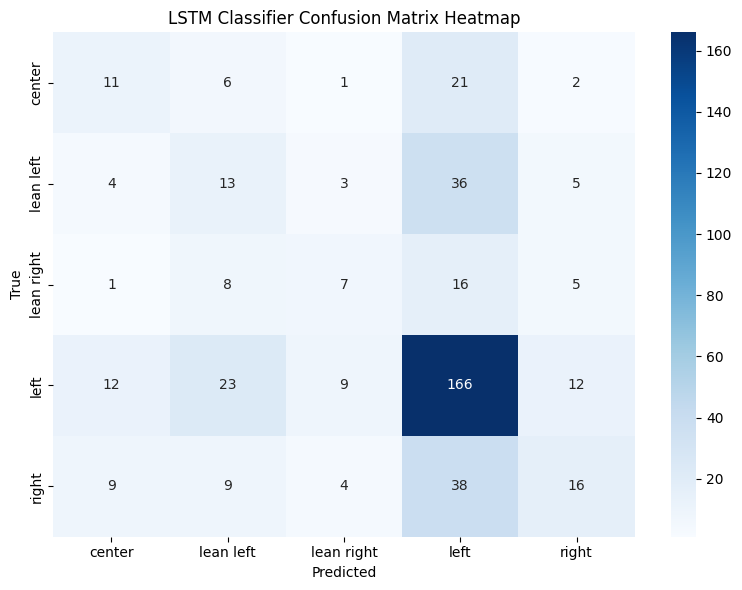

In [20]:
# 1. Get predicted and true labels
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
y_pred = best_net.predict(X_test_np)

# 2. Get label names from the model (assuming label_encoder used during training)
labels = label_encoder.classes_

# 3. Compute confusion matrix with fixed label order
cm = confusion_matrix(y_test_np, y_pred, labels=np.arange(len(labels)))

# 4. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Classifier Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get the trained model and test data
best_net = search.best_estimator_
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()

# 2. Get predictions
y_pred = best_net.predict(X_test_np)

# 3. Get class names
classes = best_net.classes_  # from skorch NeuralNetClassifier

# 4. Loop over each class for one-vs-rest confusion matrix
for i, class_label in enumerate(classes):
    y_true_binary = (y_test_np == i).astype(int)
    y_pred_binary = (y_pred == i).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{class_label}':")
    print(cm)


One-vs-Rest Confusion Matrix for class '0':
[[370  26]
 [ 30  11]]

One-vs-Rest Confusion Matrix for class '1':
[[330  46]
 [ 48  13]]

One-vs-Rest Confusion Matrix for class '2':
[[383  17]
 [ 30   7]]

One-vs-Rest Confusion Matrix for class '3':
[[104 111]
 [ 56 166]]

One-vs-Rest Confusion Matrix for class '4':
[[337  24]
 [ 60  16]]


## ROC-AUC

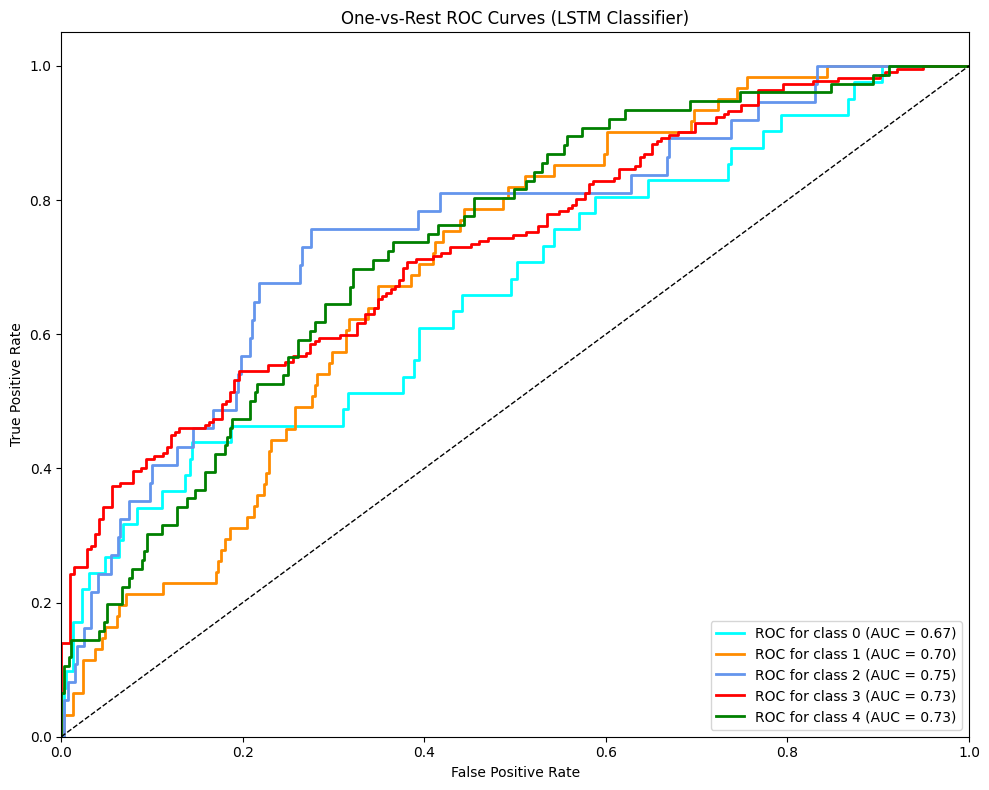

In [22]:

# 1. Get the trained model and test data
best_net = search.best_estimator_
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
classes = best_net.classes_

# 2. Binarize the true labels for One-vs-Rest
y_test_binarized = label_binarize(y_test_np, classes=range(len(classes)))

# 3. Get predicted probabilities
y_score = best_net.predict_proba(X_test_np)  # shape: (n_samples, n_classes)

# 4. Compute ROC curves and AUC for each class
fpr = {}
tpr = {}
roc_auc_dict = {}

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc_dict[c] = roc_auc_score(y_test_binarized[:, i], y_score[:, i])

# 5. Plot
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (AUC = {roc_auc_dict[c]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves (LSTM Classifier)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [23]:
macro_auc = roc_auc_score(y_test_binarized, y_score, average='macro')
print(f"Macro-average ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.7148
